# Ethereum Wallet Fraud Detection Using Machine Learning

## Objective
Analyze Ethereum wallet transaction behavior and detect suspicious/fraudulent wallets using machine learning techniques.

## Dataset
Ethereum Fraud Detection Dataset (https://www.kaggle.com/datasets/vagifa/ethereum-frauddetection-dataset)

### ERC20 Features

- ERC20 refers to a standard used for Ethereum-based tokens.

- The dataset includes several ERC20-related features that describe token transfer behavior, including transfer amounts, token diversity, and interaction patterns.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotx

pd.set_option("display.max_columns", None)
plt.style.use(matplotx.styles.github["dark"])

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('data/transaction_dataset.csv')

In [114]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
)

In [115]:
df

,Unnamed:_0,Index,Address,FLAG,Avg_min_between_sent_tnx,Avg_min_between_received_tnx,Time_Diff_between_first_and_last_(Mins),Sent_tnx,Received_Tnx,Number_of_Created_Contracts,Unique_Received_From_Addresses,Unique_Sent_To_Addresses,min_value_received,max_value_received,avg_val_received,min_val_sent,max_val_sent,avg_val_sent,min_value_sent_to_contract,max_val_sent_to_contract,avg_value_sent_to_contract,total_transactions_(including_tnx_to_create_contract,total_Ether_sent,total_ether_received,total_ether_sent_contracts,total_ether_balance,Total_ERC20_tnxs,ERC20_total_Ether_received,ERC20_total_ether_sent,ERC20_total_Ether_sent_contract,ERC20_uniq_sent_addr,ERC20_uniq_rec_addr,ERC20_uniq_sent_addr.1,ERC20_uniq_rec_contract_addr,ERC20_avg_time_between_sent_tnx,ERC20_avg_time_between_rec_tnx,ERC20_avg_time_between_rec_2_tnx,ERC20_avg_time_between_contract_tnx,ERC20_min_val_rec,ERC20_max_val_rec,ERC20_avg_val_rec,ERC20_min_val_sent,ERC20_max_val_sent,ERC20_avg_val_sent,ERC20_min_val_sent_contract,ERC20_max_val_sent_contract,ERC20_avg_val_sent_contract,ERC20_uniq_sent_token_name,ERC20_uniq_rec_token_name,ERC20_most_sent_token_type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,40,118,0.000000,45.806785,6.589513,0.000000,31.220000,1.200681,0.0,0.0,0.0,810,865.691093,586.466675,0.0,-279.224419,265.0,3.558854e+07,3.560317e+07,0.0,30.0,54.0,0.0,58.0,0.0,0.0,0.0,0.0,0.00,1.500000e+07,265586.147600,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,5,14,0.000000,2.613269,0.385685,0.000000,1.800000,0.032844,0.0,0.0,0.0,102,3.087297,3.085478,0.0,-0.001819,8.0,4.034283e+02,2.260809e+00,0.0,1.0,5.0,0.0,7.0,0.0,0.0,0.0,0.0,0.00,3.650000e+02,57.632615,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,10,2,0.113119,1.165453,0.358906,0.050000,3.538616,1.794308,0.0,0.0,0.0,12,3.588616,3.589057,0.0,0.000441,8.0,5.215121e+02,0.000000e+00,0.0,0.0,7.0,0.0,8.0,0.0,0.0,0.0,0.0,0.00,4.428198e+02,65.189009,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,7,13,0.000000,500.000000,99.488840,0.000000,450.000000,70.001834,0.0,0.0,0.0,34,1750.045862,895.399559,0.0,-854.646303,14.0,1.711105e+04,1.141223e+04,0.0,2.0,11.0,0.0,11.0,0.0,0.0,0.0,0.0,0.00,1.141223e+04,1555.550174,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,7,19,0.000000,12.802411,2.671095,0.000000,9.000000,0.022688,0.0,0.0,0.0,4619,104.318883,53.421897,0.0,-50.896986,42.0,1.628297e+05,1.235399e+05,0.0,4.0,23.0,0.0,27.0,0.0,0.0,0.0,0.0,0.00,9.000000e+04,4934.232147,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9836,9836,2175,0xff481ca14e6c16b79fc8ab299b4d2387ec8ecdd2,1,12635.10,631.39,58748.48,4,13,0,11,4,0.004082,12.000000,2.821060,0.465461,12.200000,9.166365,0.0,0.0,0.0,17,36.665461,36.673777,0.0,0.008316,2.0,1.337000e+00,0.000000e+00,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.00,1.337000e+00,0.668500,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,2.0,,GSENetwork
9837,9837,2176,0xff718805bb9199ebf024ab6acd333e603ad77c85,1,0.00,0.00,0.00,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0,0.000000,0.000000,0.0,0.000000,1.0,1.337000e+01,0.000000e+00,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,13.37,1.337000e+01,13.370000,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,1.0,,Blockwell say NOTSAFU
9838,9838,2177,0xff8e6af02d41a576a0c82f7835535193e1a6bccc,1,2499.44,2189

In [116]:
df = df.drop(columns=["Unnamed:_0", "Index", "Address"])

In [117]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
FLAG,9841.0,2.214206e-01,4.152241e-01,0.00,0.000000,0.000000e+00,0.000000,1.000000e+00
Avg_min_between_sent_tnx,9841.0,5.086879e+03,2.148655e+04,0.00,0.000000,1.734000e+01,565.470000,4.302877e+05
Avg_min_between_received_tnx,9841.0,8.004851e+03,2.308171e+04,0.00,0.000000,5.097700e+02,5480.390000,4.821755e+05
Time_Diff_between_first_and_last_(Mins),9841.0,2.183333e+05,3.229379e+05,0.00,316.930000,4.663703e+04,304070.980000,1.954861e+06
Sent_tnx,9841.0,1.159317e+02,7.572264e+02,0.00,1.000000,3.000000e+00,11.000000,1.000000e+04
Received_Tnx,9841.0,1.637009e+02,9.408366e+02,0.00,1.000000,4.000000e+00,27.000000,1.000000e+04
Number_of_Created_Contracts,9841.0,3.729702e+00,1.414456e+02,0.00,0.000000,0.000000e+00,0.000000,9.995000e+03
Unique_Received_From_Addresses,9841.0,3.036094e+01,2.986211e+02,0.00,1.000000,2.000000e+00,5.000000,9.999000e+03
Unique_Sent_To_Addresses,9841.0,2.584016e+01,2.638204e+02,0.00,1.000000,2.000000e+00,3.000000,9.287000e+03
min_value_received,9841.0,4.384515e+01,3.259291e+02,0.00,0.001000,9.585600e-02,2.000000,1.000000e+04


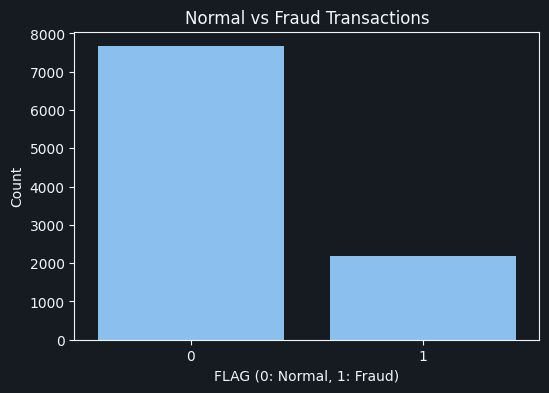

FLAG
0    77.857941
1    22.142059
Name: proportion, dtype: float64


In [119]:
df["FLAG"].value_counts()

plt.figure(figsize=(6, 4))
sns.countplot(x="FLAG", data=df)
plt.title("Normal vs Fraud Transactions")
plt.xlabel("FLAG (0: Normal, 1: Fraud)")
plt.ylabel("Count")
plt.show()

fraud_percentage = df["FLAG"].value_counts(normalize=True) * 100
print(fraud_percentage)


### Observation

The dataset is imbalanced, with significantly fewer fraud wallets compared to legitimate wallets.

This imbalance must be considered during model training and evaluation.

In [120]:
correlation = df.corr(numeric_only=True)["FLAG"].sort_values(ascending=False)

print(correlation)

FLAG                                                    1.000000
ERC20_min_val_sent                                      0.025364
ERC20_avg_val_sent                                      0.025044
ERC20_max_val_sent                                      0.025038
ERC20_total_ether_sent                                  0.024762
ERC20_total_Ether_sent_contract                         0.013514
ERC20_min_val_rec                                       0.011163
ERC20_uniq_sent_token_name                              0.009249
ERC20_avg_val_rec                                       0.007881
min_val_sent                                            0.006626
ERC20_uniq_sent_addr.1                                 -0.003047
total_ether_balance                                    -0.003229
ERC20_max_val_rec                                      -0.004313
ERC20_total_Ether_received                             -0.004475
min_value_sent_to_contract                             -0.007213
max_val_sent_to_contract 

## Finding Features with the Highest Correlation to the Fraud Label `FLAG`:

In [121]:
best_features = correlation[1:11]

<Axes: title={'center': 'Top 10 Features Correlated with Fraud (FLAG)'}, xlabel='Correlation Coefficient', ylabel='Feature'>

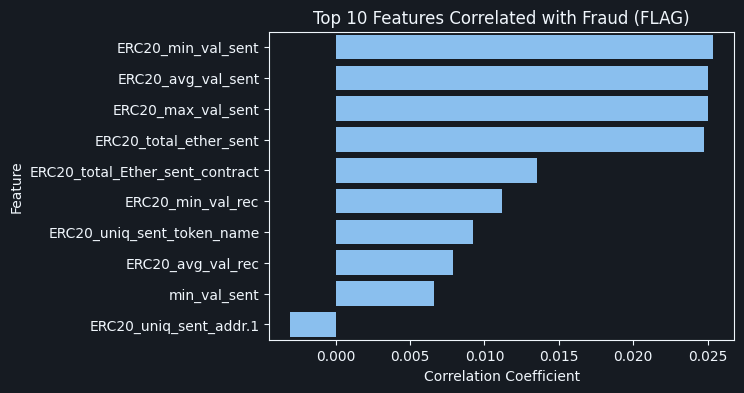

In [122]:
plt.figure(figsize=(6, 4))
plt.title("Top 10 Features Correlated with Fraud (FLAG)")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
sns.barplot(x = best_features.values, 
            y=best_features.index
)  

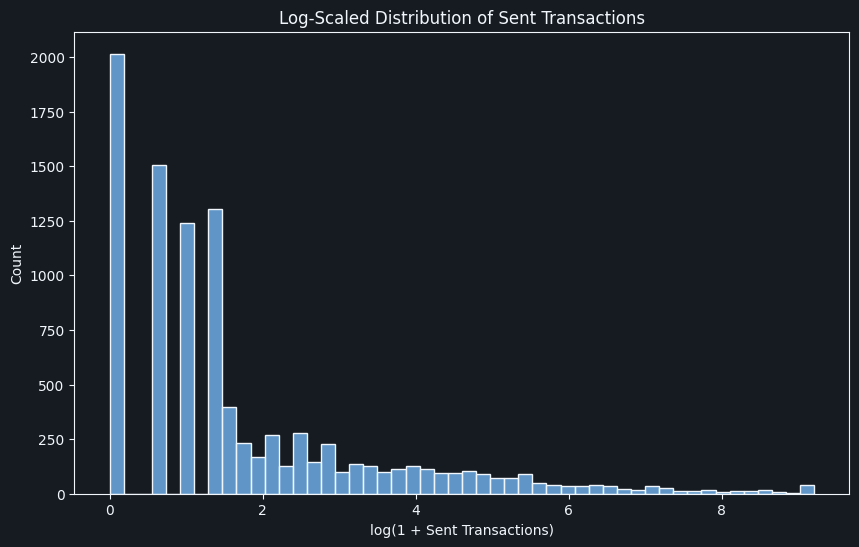

In [123]:
plt.figure(figsize=(10,6))

sns.histplot(
    np.log1p(df["Sent_tnx"]),
    bins=50
)

plt.title("Log-Scaled Distribution of Sent Transactions")
plt.xlabel("log(1 + Sent Transactions)")
plt.ylabel("Count")

plt.show()

This visualization shows the distribution of the number of transactions sent by Ethereum wallets.

The original `Sent tnx` feature was heavily right-skewed, meaning:

- Most wallets sent very few transactions
- A small number of wallets sent extremely large numbers of transactions

These outliers compressed the histogram and made the majority of the data difficult to visualize clearly.

To better interpret the histogram, we applied a logarithmic transformation using:

log(1 + Sent tnx)

### Key Insights

- Most wallets exhibit relatively low transaction activity
- A small number of wallets are extremely active
- The dataset contains significant outliers
- Wallet activity is not normally distributed

## Behaviourial Analysis of Normal and Fraud Wallets:

Now, we investigate the behaviourial distributions between the normal and fraud wallets

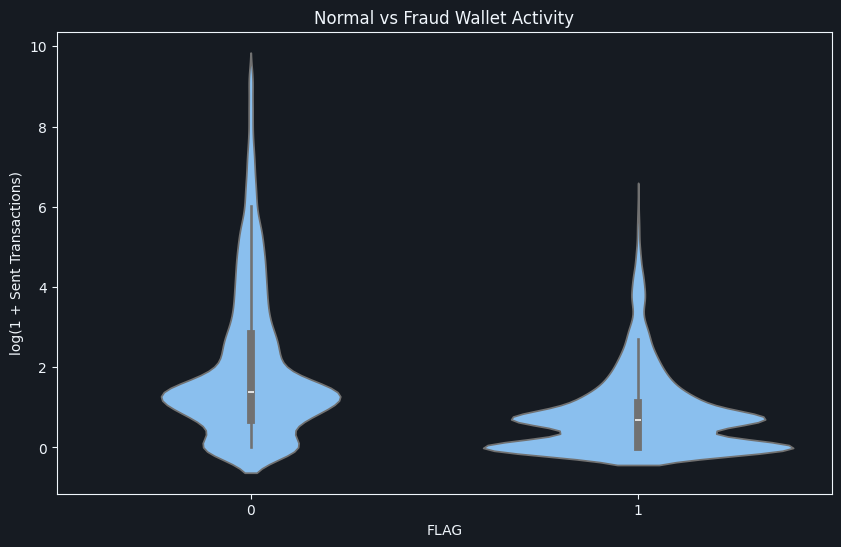

In [124]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x=df["FLAG"],
    y=np.log1p(df["Sent_tnx"])
)

plt.title("Normal vs Fraud Wallet Activity")
plt.xlabel("FLAG")
plt.ylabel("log(1 + Sent Transactions)")

plt.show()

### Observation

- Normal wallets generally exhibit higher transaction activity compared to fraud wallets.

- The fraud wallets are more concentrated around lower transaction counts, while normal wallets show a wider range of activity.

The top features correlated with Fraud Label `FLAG` are:
- ERC20 min val sent
- ERC20 avg val sent
- ERC20 max val sent
- ERC20 total ether sent


Most of them are related to ERC20 token transfer behavior, suggesting that token activity patterns may be more useful for fraud detection compared to single coin transactions/activity.

In [125]:
important_features = [
    "ERC20 min val sent",
    "ERC20 avg val sent",
    "ERC20 max val sent",
    "ERC20 total ether sent"
]

Now, we create a function that visualizes the behaviour of the Fraud Label `FLAG` for a feature

In [126]:
def compare_feature(feature_name):

    plt.figure(figsize=(10,6))

    sns.violinplot(
        x=df["FLAG"],
        y=np.log1p(df[feature_name])
    )

    plt.title(f"Normal vs Fraud Wallet: {feature_name}")

    plt.xlabel("FLAG")
    plt.ylabel(f"log(1 + {feature_name})")

    plt.show()

### 1. ERC20_min_val_sent:

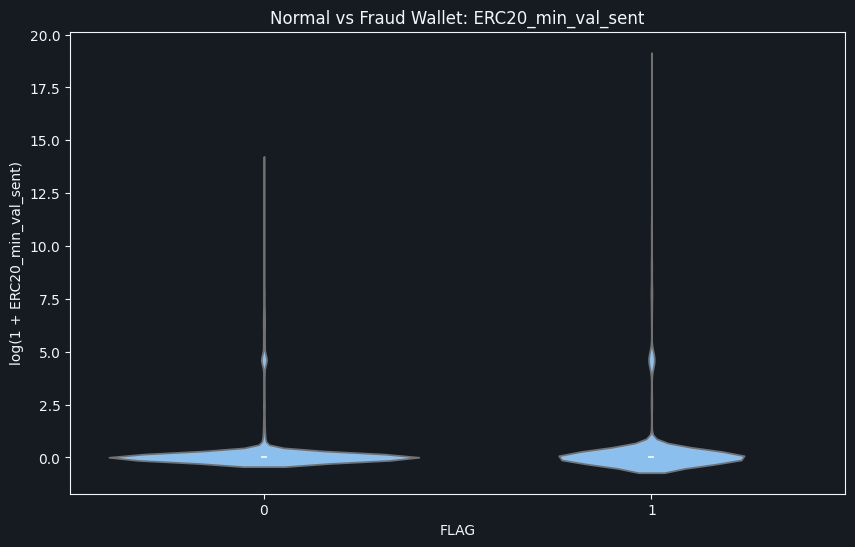

In [127]:
compare_feature("ERC20_min_val_sent")

### 2. ERC20_avg_val_sent:

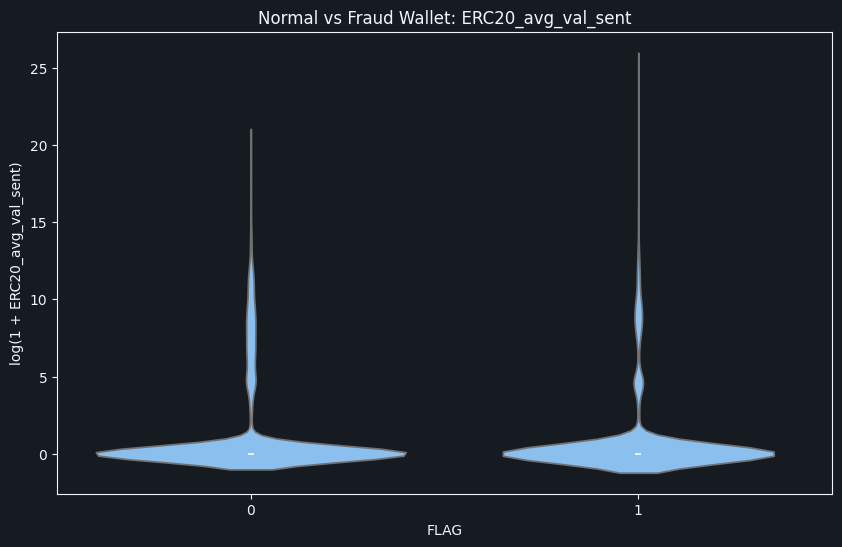

In [128]:
compare_feature("ERC20_avg_val_sent")

### 3. ERC20_max_val_sent:

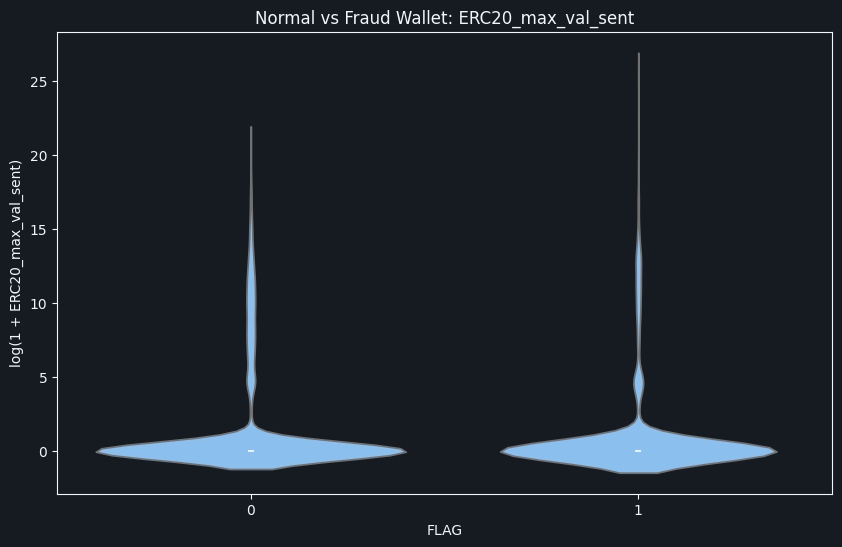

In [129]:
compare_feature("ERC20_max_val_sent")

### 4. ERC20_total_ether_sent:

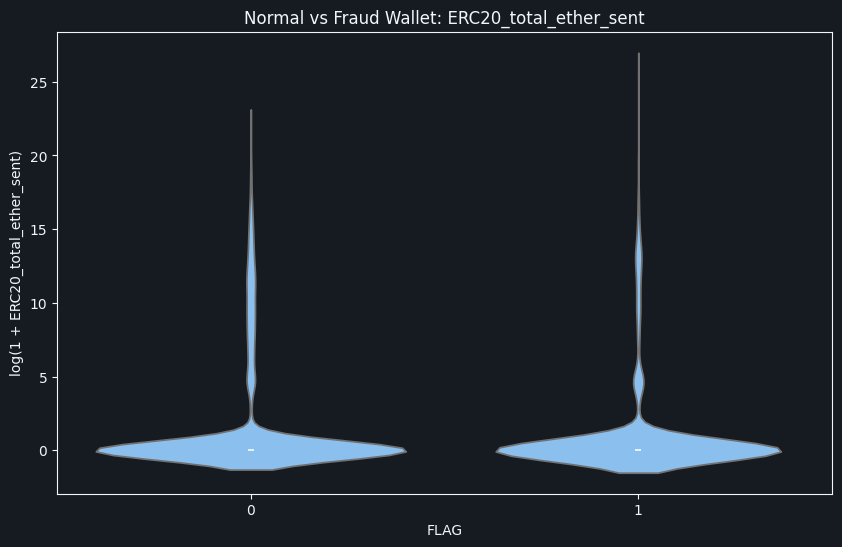

In [130]:
compare_feature("ERC20_total_ether_sent")

#### Normal Wallets (FLAG = 0) show:

- broader distributions
- greater variability
- more diverse transfer behavior

while:

#### Fraud Wallets (FLAG = 1) show:

- more concentrated distributions
- narrower behavioural spread
- stronger clustering near low values

### Observation — ERC20 Transfer Behaviour

The ERC20-related transfer features exhibit noticeable behavioral differences between fraudulent and legitimate wallets.

- Fraud wallets appear more concentrated around lower ERC20 transfer values and show narrower behavioural distributions overall.

- Normal wallets exhibit greater variability and broader transfer behaviour across average, maximum, and total ERC20 transfer metrics.

- This suggests that normal wallets show using more constrained or repetitive token transfer patterns, while normal wallets show more diverse transactional behaviour.

## Data Preprocessing:

In [131]:
print(df.shape)

(9841, 48)


#### Checking & Handling Missing Values:

In [132]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)



ERC20_most_sent_token_type             2697
ERC20_most_rec_token_type               871
ERC20_total_ether_sent                  829
ERC20_total_Ether_received              829
ERC20_uniq_sent_addr                    829
ERC20_uniq_rec_addr                     829
ERC20_uniq_sent_addr.1                  829
ERC20_total_Ether_sent_contract         829
Total_ERC20_tnxs                        829
ERC20_avg_time_between_sent_tnx         829
ERC20_uniq_rec_contract_addr            829
ERC20_avg_time_between_rec_tnx          829
ERC20_avg_time_between_rec_2_tnx        829
ERC20_max_val_rec                       829
ERC20_avg_val_rec                       829
ERC20_avg_time_between_contract_tnx     829
ERC20_min_val_rec                       829
ERC20_max_val_sent                      829
ERC20_min_val_sent                      829
ERC20_avg_val_sent                      829
ERC20_min_val_sent_contract             829
ERC20_avg_val_sent_contract             829
ERC20_max_val_sent_contract     

For this project, missing numerical values will be replaced using the median value of each feature.

In [133]:
cols = df.select_dtypes(include = np.number).columns

for col in cols:
    df[col] = df[col].fillna(df[col].median())

#### Converting Categorical Features into Numbers using Label Encoding:

In [134]:
categorical_cols = df.select_dtypes(include = "object").columns

categorical_cols

Index(['ERC20_most_sent_token_type', 'ERC20_most_rec_token_type'], dtype='object')

In [136]:
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9841 entries, 0 to 9840
Data columns (total 48 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   FLAG                                                  9841 non-null   int64  
 1   Avg_min_between_sent_tnx                              9841 non-null   float64
 2   Avg_min_between_received_tnx                          9841 non-null   float64
 3   Time_Diff_between_first_and_last_(Mins)               9841 non-null   float64
 4   Sent_tnx                                              9841 non-null   int64  
 5   Received_Tnx                                          9841 non-null   int64  
 6   Number_of_Created_Contracts                           9841 non-null   int64  
 7   Unique_Received_From_Addresses                        9841 non-null   int64  
 8   Unique_Sent_To_Addresses                              9841

#### Separating Data into Features and Labels:
- X - input features
- y - target labels

In [138]:
X = df.drop(columns=["FLAG"])

y = df["FLAG"]

#### Feature Scaling:
Used because:
- Transaction values vary enormously
- Data contains extreme outliers
- Some features use vastly different scales


In [140]:
sc = StandardScaler()

X_scaled = sc.fit_transform(X)

#### Train-Test Split: (80-20)

In [141]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=18, stratify=y
)

In [142]:
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)

Training Features Shape: (7872, 47)
Testing Features Shape: (1969, 47)
Training Labels Shape: (7872,)
Testing Labels Shape: (1969,)
